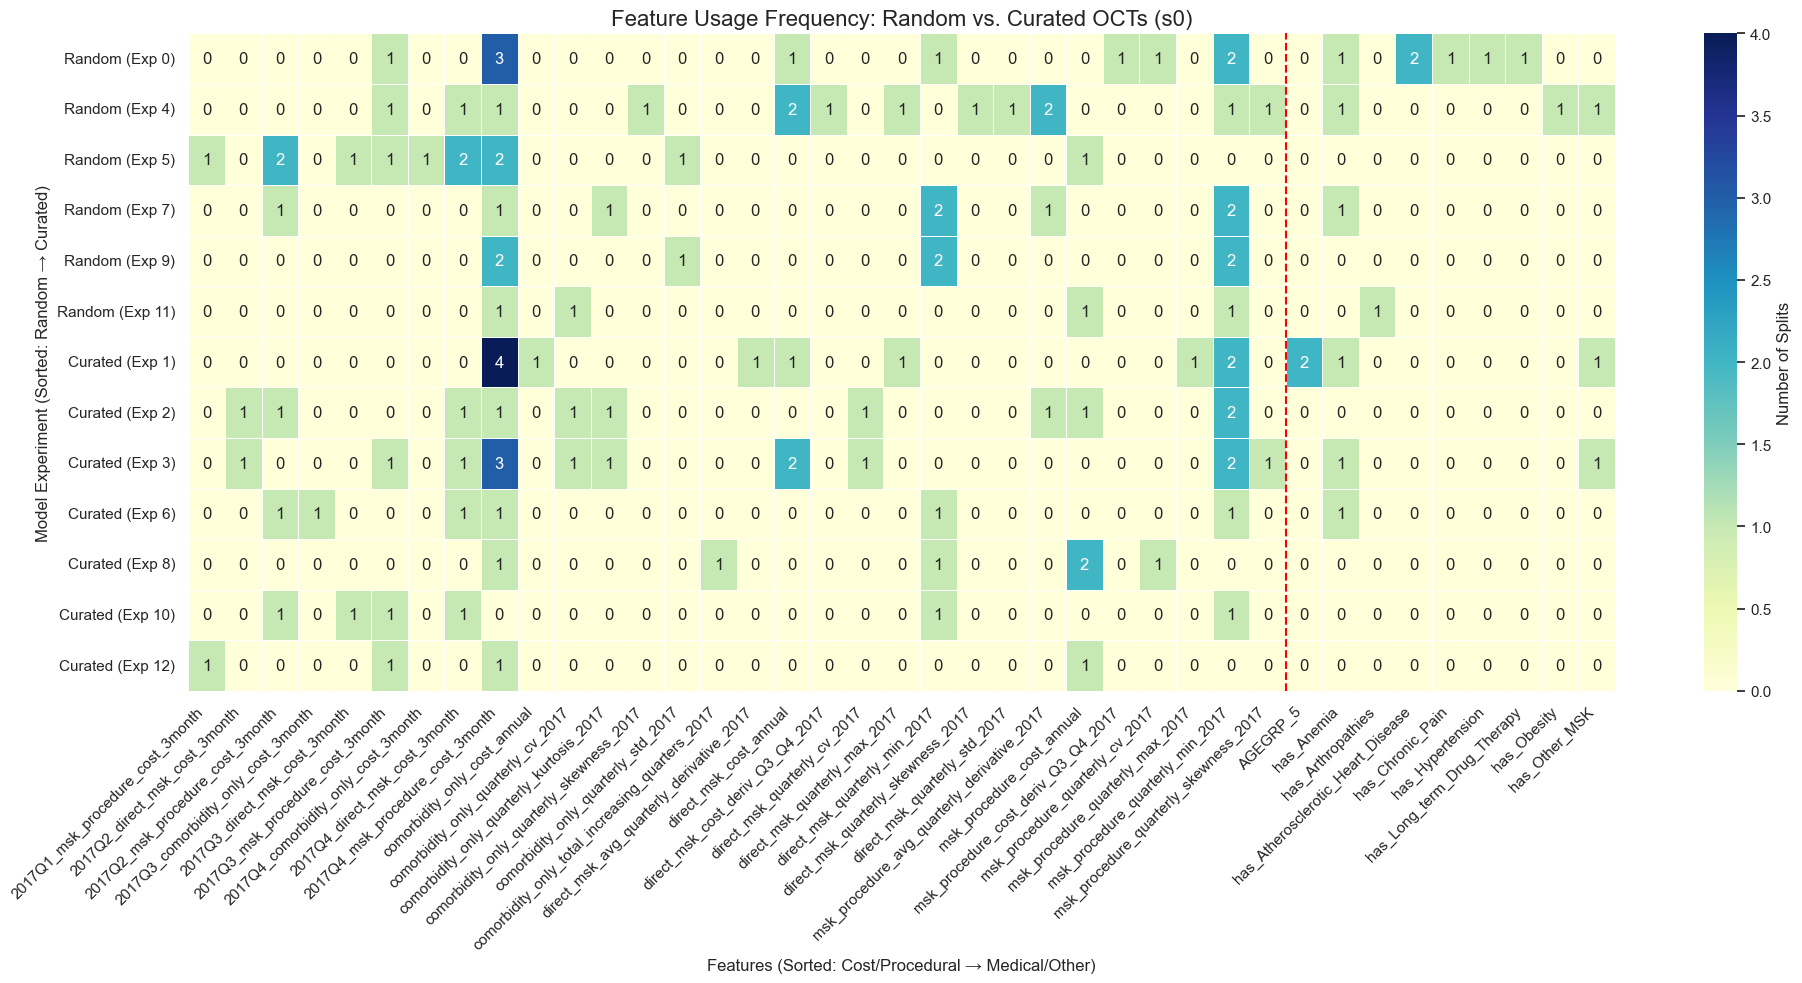

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

def plot_feature_split_heatmap(folder_path="exp_random_vs_curation_all_features_smart_seed/results", seed = "0"):
    base_path = Path(folder_path)
    all_files = list(base_path.glob(f"oct_tree_exp*_s{seed}_splits.csv"))
    
    # 1. Load data and identify all unique features
    model_data = []
    unique_features = set()
    
    for f_path in all_files:
        fname = f_path.name.lower()
        method = "Random" if "random" in fname else "Curated"
        
        # Extract Exp number (e.g., exp1)
        exp_match = re.search(r'exp(\d+)', fname)
        exp_num = int(exp_match.group(1)) if exp_match else 0
        
        df = pd.read_csv(f_path)
        # Count splits per feature in this tree
        counts = df['feature'].value_counts().to_dict()
        unique_features.update(counts.keys())
        
        counts['Method_Prefix'] = method
        counts['Exp_Num'] = exp_num
        counts['Model_ID'] = f"{method} (Exp {exp_num})"
        model_data.append(counts)

    # 2. Create Matrix
    matrix_df = pd.DataFrame(model_data).set_index('Model_ID').fillna(0)
    
    # 3. SORTING LOGIC
    # X-AXIS: Cost Columns First, then Others
    def is_cost_col(col):
        c = col.lower()
        keywords = ["cost", "quarterly", "increasing", "decreasing", "skewness", "kurtosis", "cv", "range"]
        is_cost = any(k in c for k in keywords) and "2018" not in c
        return 0 if is_cost else 1 # 0 comes before 1 in sort

    sorted_features = sorted(list(unique_features), key=lambda x: (is_cost_col(x), x))
    
    # Y-AXIS: Random then Curated, then by Exp Number
    # We create a temporary sorting key
    matrix_df['sort_key'] = matrix_df['Method_Prefix'].apply(lambda x: 0 if x == "Random" else 1)
    matrix_df = matrix_df.sort_values(by=['sort_key', 'Exp_Num'])
    
    # Clean up for plotting
    plot_df = matrix_df[sorted_features]

    # 4. Visualization
    plt.figure(figsize=(20, 10))
    sns.set_theme(style="white")
    
    # Use a sequential colormap to show split density
    ax = sns.heatmap(plot_df, annot=True, fmt=".0f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'Number of Splits'})

    plt.title("Feature Usage Frequency: Random vs. Curated OCTs (s0)", fontsize=16)
    plt.xlabel("Features (Sorted: Cost/Procedural → Medical/Other)", fontsize=12)
    plt.ylabel("Model Experiment (Sorted: Random → Curated)", fontsize=12)
    
    # Visual divider for Cost vs Medical
    num_cost = len([f for f in sorted_features if is_cost_col(f) == 0])
    plt.axvline(x=num_cost, color='red', linestyle='--', label='Cost/Medical Boundary')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_split_comparison.png', dpi=300)
    plt.show()



folder_path = "kmeanspp_exp_random_vs_curation_medical_only_for_prediction/results"
plot_feature_split_heatmap(folder_path,seed = "42")

Plot saved as 's42_majority_cost_boxplot.png'


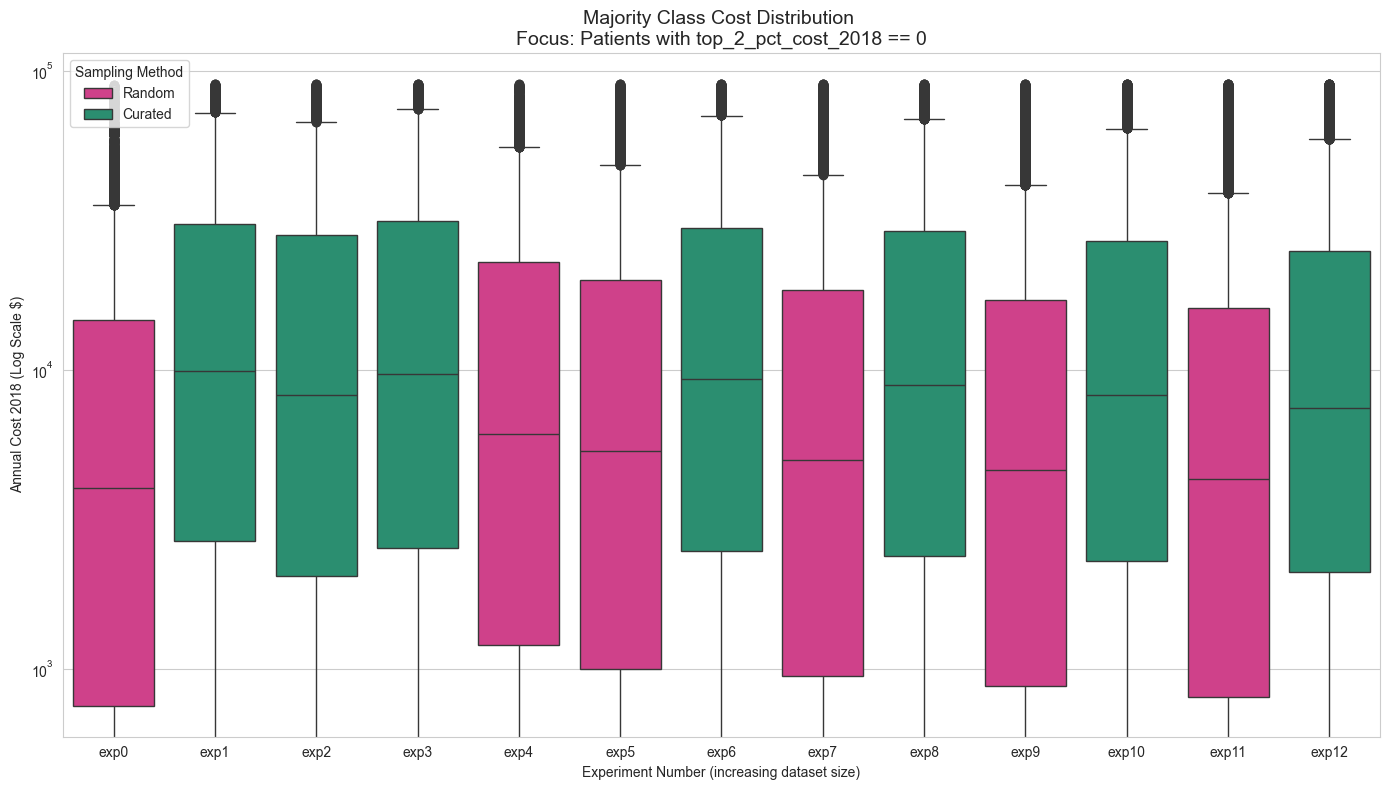

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re
import os
from matplotlib.lines import Line2D

def plot_majority_cost_by_experiment(folder_path="exp_random_vs_curation_all_features_smart_seed/results"):
    base_path = Path(folder_path)
    # 1. Find all csv files starting with exp
    all_files = list(base_path.glob("exp*.csv"))
    
    target_col = "annual_cost_2018_deflated"
    filter_col = "top_2_pct_cost_2018"
    
    data_list = []
    
    for f_path in all_files:
        fname = f_path.name.lower()
        
        # 2. Filter: Only 's0' files, exclude 's42'
        if "s0" in fname and "s42" not in fname:
            # Determine Method
            method = "Random" if "random" in fname else "Curated"
            
            # Extract Exp Number (e.g. 'exp1', 'exp2') for sorting
            exp_match = re.search(r'(exp\d+)', fname)
            exp_id = exp_match.group(1) if exp_match else "unknown"
            
            try:
                # Load only required columns
                df = pd.read_csv(f_path, usecols=[target_col, filter_col])
                
                # 3. Filter for Majority Class (Target = 0)
                # This focuses the visualization on how we are shifting the "Non-High Cost" patients
                majority_df = df[df[filter_col] == 0].copy()
                
                # Add metadata for plotting
                majority_df['Method'] = method
                majority_df['Experiment'] = exp_id
                # Extract numeric part for sorting: exp1 -> 1
                majority_df['Exp_Order'] = int(re.search(r'\d+', exp_id).group())
                
                data_list.append(majority_df)
            except Exception as e:
                print(f"Skipping {fname} due to error: {e}")

    if not data_list:
        print("No files matched the criteria (s0 found, no s42, starting with 'exp').")
        return

    # Combine all experiments
    full_df = pd.concat(data_list, ignore_index=True)
    
    # 4. Sort by Experiment Order (Dataset Size)
    full_df = full_df.sort_values(by=['Exp_Order', 'Method'])

    # 5. Plotting
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # High-contrast palette: Teal for Curated, Pink for Random
    palette = {"Curated": "#1b9e77", "Random": "#e7298a"}
    
    ax = sns.boxplot(
        data=full_df, 
        x="Experiment", 
        y=target_col, 
        hue="Method",
        palette=palette,
        showfliers=True # Removes outliers to focus on the IQR comparison
    )
    
    # 6. Log Scale is essential for healthcare cost data
    plt.yscale('log')
    
    plt.title(f"Majority Class Cost Distribution \nFocus: Patients with {filter_col} == 0", fontsize=14)
    plt.ylabel("Annual Cost 2018 (Log Scale $)")
    plt.xlabel("Experiment Number (increasing dataset size)")
    
    # Clean up formatting
    plt.xticks(rotation=0)
    plt.legend(title="Sampling Method", loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f'{folder_path}/s42_majority_cost_boxplot.png', dpi=300)
    print("Plot saved as 's42_majority_cost_boxplot.png'")
    plt.show()

# To run the function, ensure the path points to your results folder:
plot_majority_cost_by_experiment()

In [22]:
import re
from pathlib import Path
from typing import Union, List, Callable, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_gmean_recall_specificity_by_identifier(
    csv_path: Union[str, Path],
    identifier_cols: Union[str, List[str]],
    color_metric: str = "pr_auc",  # canonical metric name after aliasing
    label_fn: Optional[Callable[[pd.Series], str]] = None,
    title: Optional[str] = None,
    aliases: Optional[Dict[str, str]] = None,
    require_seed: Optional[bool] = None,
    drop_missing_xy: bool = True,
    use_adjust_text: bool = True,
    figsize=(12, 6),
    point_size=220,
    alpha=0.9,
    return_data: bool = False,
):
    """
    Flexible plotting function for experiment CSVs with varying column names.

    Canonical columns used internally:
      - auc, pr_auc, best_mcc
      - balanced_recall_gmean, balanced_specificity_gmean
      - seed
    """

    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    # -----------------------------
    # 1) Alias columns -> canonical names
    # -----------------------------
    # user-provided aliases override defaults
    default_aliases = {
        # test metric variants
        "test_auc": "auc",
        "test_pr_auc": "pr_auc",
        "test_best_mcc": "best_mcc",

        # sometimes files already carry *_mean in row-level summaries
        "balanced_recall_gmean_mean": "balanced_recall_gmean",
        "balanced_specificity_gmean_mean": "balanced_specificity_gmean",

        # allow older names to pass through unchanged (no-op if absent)
        "auc": "auc",
        "pr_auc": "pr_auc",
        "best_mcc": "best_mcc",
        "balanced_recall_gmean": "balanced_recall_gmean",
        "balanced_specificity_gmean": "balanced_specificity_gmean",
        "seed": "seed",
    }
    if aliases:
        default_aliases.update(aliases)

    rename_map = {c: default_aliases[c] for c in df.columns if c in default_aliases}
    df = df.rename(columns=rename_map)

    # -----------------------------
    # 2) Numeric coercion
    # -----------------------------
    maybe_numeric = [
        "seed", "ratio", "nP", "nC", "n_cases", "n_controls",
        "best_depth", "best_minbucket", "best_cp", "num_leaves",
        "auc", "pr_auc", "best_mcc",
        "balanced_recall_gmean", "balanced_specificity_gmean",
        "matching_time_s", "matching_time_seconds",
        "matching_mean_cost",
        "M", "M_pct_of_controls",
    ]
    for c in maybe_numeric:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # -----------------------------
    # 3) Identifier columns
    # -----------------------------
    if isinstance(identifier_cols, str):
        group_cols = [identifier_cols]
    else:
        group_cols = list(identifier_cols)

    missing = [c for c in group_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing identifier columns {missing}. Available columns: {list(df.columns)}")

    # -----------------------------
    # 4) Seed filtering (optional)
    # -----------------------------
    # If require_seed is None:
    # - keep all rows by default (important for files with curated rows having blank seed)
    # - user can set True if they want only seeded rows
    if require_seed is True and "seed" in df.columns:
        df = df[df["seed"].notna()].copy()
    elif require_seed is False:
        df = df.copy()

    if df.empty:
        raise ValueError("No rows remaining after filtering.")

    # -----------------------------
    # 5) Validate core plot columns
    # -----------------------------
    x_base = "balanced_recall_gmean"
    y_base = "balanced_specificity_gmean"

    if x_base not in df.columns or y_base not in df.columns:
        raise KeyError(
            "Need columns for recall/specificity at G-mean. "
            f"Found columns: {list(df.columns)}"
        )

    # -----------------------------
    # 6) Aggregate by identifiers
    # -----------------------------
    agg_candidates = [
        "auc", "pr_auc", "best_mcc",
        "balanced_recall_gmean", "balanced_specificity_gmean"
    ]
    agg_cols = [c for c in agg_candidates if c in df.columns]

    agg_df = (
        df.groupby(group_cols)[agg_cols]
          .agg(["mean", "std", "count"])
          .reset_index()
    )
    agg_df.columns = ["_".join([str(c) for c in col if c]) for col in agg_df.columns.values]

    x_col = "balanced_recall_gmean_mean"
    y_col = "balanced_specificity_gmean_mean"
    c_col = f"{color_metric}_mean"

    if x_col not in agg_df.columns or y_col not in agg_df.columns:
        raise KeyError(f"Aggregated x/y columns missing. Got columns: {list(agg_df.columns)}")
    if c_col not in agg_df.columns:
        raise KeyError(
            f"Color metric '{color_metric}' not found after aggregation. "
            f"Available means: {[c for c in agg_df.columns if c.endswith('_mean')]}"
        )

    plot_df = agg_df.copy()
    if drop_missing_xy:
        plot_df = plot_df.dropna(subset=[x_col, y_col])

    if plot_df.empty:
        raise ValueError("No rows to plot after dropping missing x/y.")

    # -----------------------------
    # 7) Labels
    # -----------------------------
    def default_label(row: pd.Series) -> str:
        return " | ".join(f"{c}={row[c]}" for c in group_cols)

    plot_df["label"] = plot_df.apply(label_fn or default_label, axis=1)

    # -----------------------------
    # 8) Plot
    # -----------------------------
    x = plot_df[x_col].to_numpy()
    y = plot_df[y_col].to_numpy()
    c = plot_df[c_col].to_numpy()
    labels = plot_df["label"].astype(str).to_numpy()

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    sc = ax.scatter(x, y, c=c, s=point_size, alpha=alpha)

    ax.set_title(title or f"Recall vs Specificity at G-mean threshold ({', '.join(group_cols)})")
    ax.set_xlabel("Recall @ G-mean threshold")
    ax.set_ylabel("Specificity @ G-mean threshold")
    ax.grid(True, alpha=0.25)

    texts = [ax.text(xi, yi, lab, fontsize=9) for xi, yi, lab in zip(x, y, labels)]

    if use_adjust_text:
        try:
            from adjustText import adjust_text
            adjust_text(
                texts, ax=ax,
                expand_points=(1.2, 1.2),
                expand_text=(1.2, 1.2),
                force_points=(0.5, 0.5),
                force_text=(0.5, 0.5),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
            )
        except ImportError:
            print("adjustText not installed; skipping label adjustment.")

    xmin = max(0, float(np.nanmin(x)) - 0.05)
    xmax = min(1, float(np.nanmax(x)) + 0.05)
    ymin = max(0, float(np.nanmin(y)) - 0.05)
    ymax = min(1, float(np.nanmax(y)) + 0.05)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    cbar = fig.colorbar(sc, ax=ax, location="right", shrink=0.92, pad=0.02)
    cbar.set_label(f"{color_metric} (mean)")

    plt.show()

    if return_data:
        return df, agg_df, plot_df, fig, ax

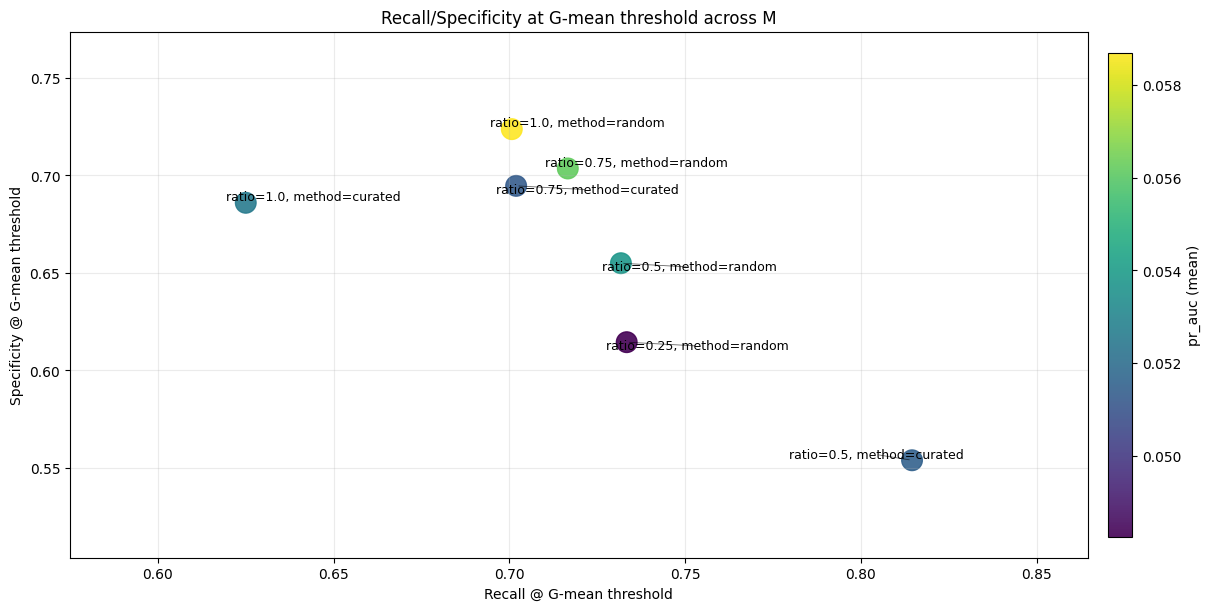

In [42]:
plot_gmean_recall_specificity_by_identifier(
    csv_path="random_vs_curated_small_ratios_kmeanspp/random_vs_curated_comparison.csv",
    identifier_cols=["ratio", "method"],
    color_metric="pr_auc",
    label_fn=lambda row: f"ratio={float(row['ratio'])}, method={row['method']}" if pd.notna(row["ratio"]) else "ratio=?, method=?",
    title="Recall/Specificity at G-mean threshold across M",
)

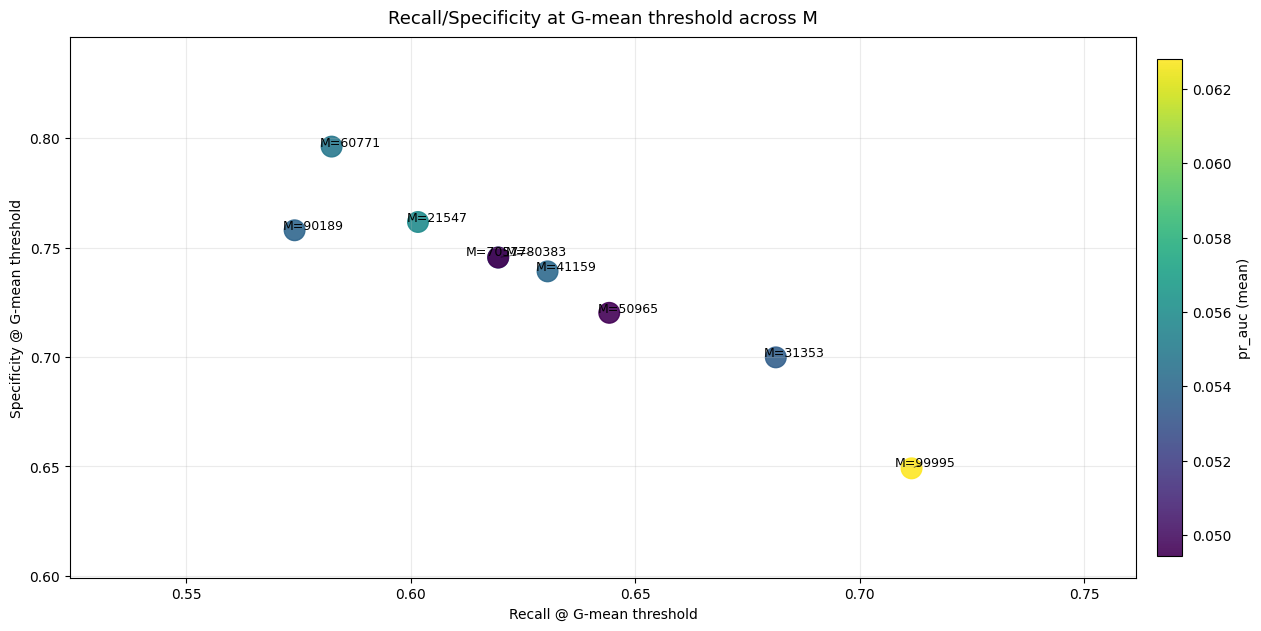

In [16]:
plot_gmean_recall_specificity_by_identifier(
    csv_path="sensitivity_medical_only_features_150_minbucket_kmeanspp/results/sensitivity_pool_size.csv",
    identifier_cols="M",
    color_metric="pr_auc",
    label_fn=lambda row: f"M={int(row['M'])}" if pd.notna(row["M"]) else "M=?",
    title="Recall/Specificity at G-mean threshold across M",
)

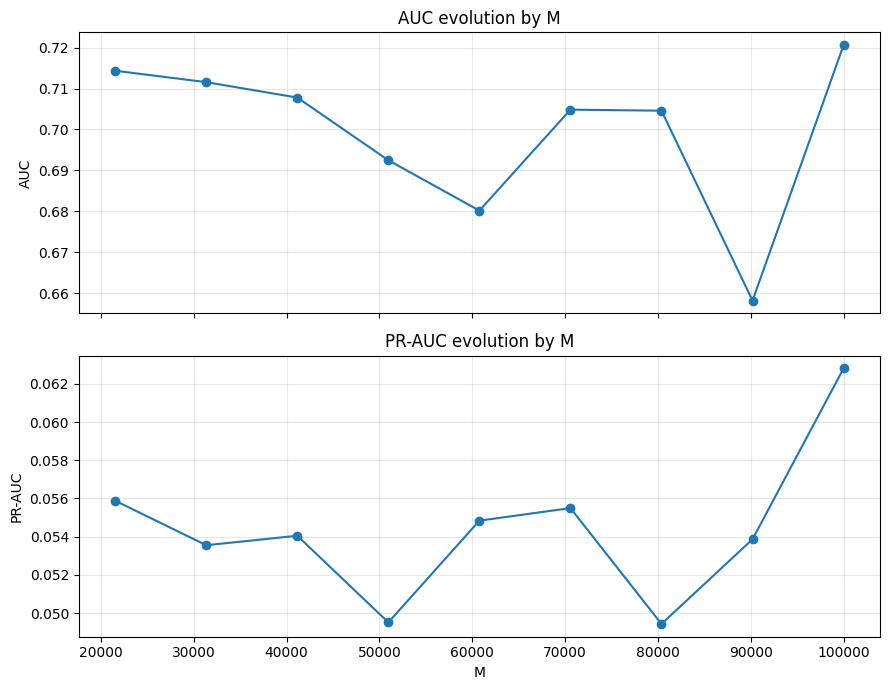

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("sensitivity_medical_only_features_150_minbucket_kmeanspp/results/sensitivity_pool_size.csv").sort_values("M").reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# AUC vs M
axes[0].plot(df["M"], df["auc"], marker="o")
axes[0].set_ylabel("AUC")
axes[0].set_title("AUC evolution by M")
axes[0].grid(True, alpha=0.3)

# PR-AUC vs M
axes[1].plot(df["M"], df["pr_auc"], marker="o")
axes[1].set_xlabel("M")
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("PR-AUC evolution by M")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Save comparison CSV
import pandas as pd
import os

comp_path = os.path.join("./xgb_matching_ratio_results_kmeanspp/", "comparison_random_vs_kcenter.csv")
comp_df = pd.read_csv(comp_path)
kcenter_rows = comp_df[comp_df["source"] == 'kcenter']
random_rows = comp_df[comp_df["source"] == 'random']


import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["pr_auc", "auc"]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric], "o-", label="k-center (no weight)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    means = rnd_agg["mean"].values
    stds = rnd_agg["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="s--", capsize=4, label=f"random (5 seeds)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
# Plot: Recall(G-mean), specificity(G-mean), recall(MCC), specificity(MCC), recall(F1), specificity(F1) - k-center line vs random mean ± std
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, [("balanced_recall_gmean", "balanced_specificity_gmean")]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric[0]], "o-", label="recall (k-center)", color="C0", linewidth=2)
    ax.plot(kc_df["matching_ratio"], kc_df[metric[1]], "s-", label="specificity (k-center)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric[0]].agg(["mean", "std"])
    rnd_agg2 = rnd_df.groupby("matching_ratio")[metric[1]].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    rnd_agg2 = rnd_agg2.reindex(ratios_plot)
    means, means2 = rnd_agg["mean"].values, rnd_agg2["mean"].values
    stds, stds2 = rnd_agg["std"].values, rnd_agg2["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="o--", capsize=4, label=f"recall (random)", color="C1")
    ax.errorbar(ratios_plot, means2, yerr=stds2, fmt="s--", capsize=4, label=f"specificity (random)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric[0].upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
plt.show()
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, [("balanced_recall_gmean", "balanced_specificity_gmean")]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric[0]], "o-", label="recall (k-center)", color="C0", linewidth=2)
    ax.plot(kc_df["matching_ratio"], kc_df[metric[1]], "s-", label="specificity (k-center)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric[0]].agg(["mean", "std"])
    rnd_agg2 = rnd_df.groupby("matching_ratio")[metric[1]].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    rnd_agg2 = rnd_agg2.reindex(ratios_plot)
    means, means2 = rnd_agg["mean"].values, rnd_agg2["mean"].values
    stds, stds2 = rnd_agg["std"].values, rnd_agg2["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="o--", capsize=4, label=f"recall (random)", color="C1")
    ax.errorbar(ratios_plot, means2, yerr=stds2, fmt="s--", capsize=4, label=f"specificity (random)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric[0].upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
plt.show()

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_43631/1666403380.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
out_path="landscape_plot_kmeanspp.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
out_path


'landscape_plot_kmeanspp.png'

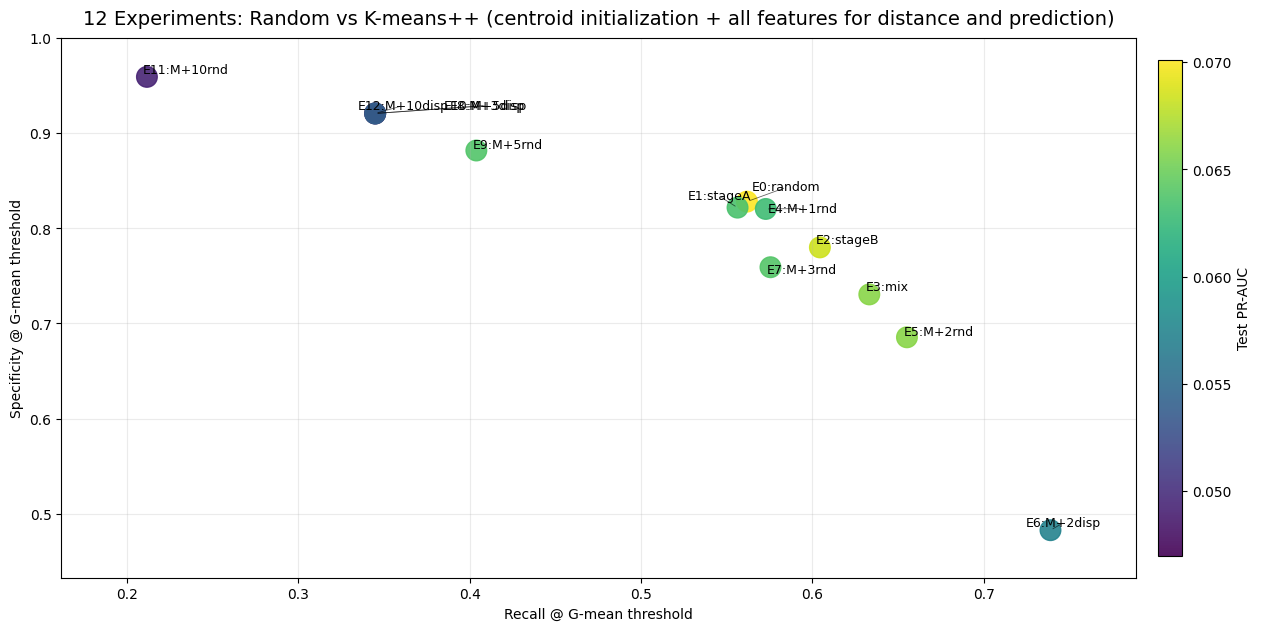

In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

path = "kmeanspp_exp_random_vs_curation_all_features_centroid/results/experiment_summary.csv"
lines = Path(path).read_text().splitlines()

HEADER = next(csv.reader([lines[0]]))  # 20 cols
ALT_COLUMNS = [  # 21 cols (your appended format)
    "experiment","variant","seed","n_cases","n_controls",
    "auc","pr_auc","best_mcc","recall_mcc","specificity_mcc",
    "precision_mcc",  # often blank
    "optimal_f1",
    "balanced_recall_gmean","balanced_specificity_gmean",
    "num_leaves","best_depth","best_minbucket","best_cp",
    "recall_at_specificity_0.6","achieved_specificity_0.6","threshold_specificity_0.6"
]
rows = []
for ln in lines[1:]:
    if not ln.strip():
        continue
    cols = next(csv.reader([ln]))
    if len(cols) == len(HEADER):
        rows.append(dict(zip(HEADER, cols)))
    elif len(cols) == len(ALT_COLUMNS):
        rows.append(dict(zip(ALT_COLUMNS, cols)))
    else:
        # unknown format -> skip
        continue

df_raw = pd.DataFrame(rows)

# numeric coercion
num_cols = [
    "seed","n_cases","n_controls","best_depth","best_minbucket","best_cp","num_leaves",
    "auc","pr_auc","best_mcc","recall_mcc","specificity_mcc","precision_mcc","optimal_f1",
    "balanced_recall_gmean","balanced_specificity_gmean",
]
for c in num_cols:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

# keep only “real per-seed” rows (best_depth present)
#df = df_raw[df_raw["best_depth"].notna()].copy()
df = df_raw[df_raw["seed"].notna()]
df["seed"] = df["seed"].astype(int)

def agg(df, group_cols):
    agg_cols = ["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
    agg_cols = [c for c in agg_cols if c in df.columns]
    out = (df.groupby(group_cols)[agg_cols]
             .agg(["mean","std","count"])
             .reset_index())
    out.columns = ["_".join([c for c in col if c]) for col in out.columns.values]
    return out

exp_agg = agg(df, ["experiment","variant"])

def make_label(exp, var):
    if exp == "random_undersample":
        return "RND"
    m = re.match(r"exp(\d+)", str(exp))
    if not m:
        return f"{exp}"
    num = int(m.group(1))
    if num <= 3:
        return f"E{num}:{var}"
    mm = re.match(r"matched_1N_plus_(\d+)N_(.*)", str(var))
    if mm:
        mult = mm.group(1)
        typ = mm.group(2)
        typ_short = "rnd" if typ == "random" else ("disp" if typ == "max_dispersed" else typ[:4])
        return f"E{num}:M+{mult}{typ_short}"
    return f"E{num}:{var}"

plot_df = exp_agg.copy()
plot_df["label"] = [make_label(e,v) for e,v in zip(plot_df["experiment"], plot_df["variant"])]

x = plot_df["balanced_recall_gmean_mean"].values
y = plot_df["balanced_specificity_gmean_mean"].values
c = plot_df["pr_auc_mean"].values
labels = plot_df["label"].astype(str).values

fig, ax = plt.subplots(figsize=(12.5, 6.2), constrained_layout=True)
sc = ax.scatter(x, y, c=c, s=220, alpha=0.9)
ax.set_title("12 Experiments: Random vs K-means++ (centroid initialization + all features for distance and prediction)", fontsize=14, pad=10)
ax.set_xlabel("Recall @ G-mean threshold")
ax.set_ylabel("Specificity @ G-mean threshold")
ax.grid(True, alpha=0.25)

from adjustText import adjust_text

texts = []
for xi, yi, lab in zip(x, y, labels):
    texts.append(ax.text(xi, yi, lab, fontsize=9))

adjust_text(
    texts, ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    force_points=(0.5, 0.5),
    force_text=(0.5, 0.5),
    arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
)
xmin = max(0, float(np.nanmin(x)) - 0.05); xmax = min(1, float(np.nanmax(x)) + 0.05)
ymin = max(0, float(np.nanmin(y)) - 0.05); ymax = min(1, float(np.nanmax(y)) + 0.05)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cbar = fig.colorbar(sc, ax=ax, location="right", shrink=0.92, pad=0.02)
cbar.set_label("Test PR-AUC", rotation=90)

plt.show()
